In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
stocks = ['TSLA','RELIANCE.NS','TCS.NS']
data = yf.download(stocks, start="2025-01-01", end="2026-04-30")
data=data.fillna(method='ffill')
data

C:\Users\rohit\AppData\Local\Temp\ipykernel_19044\4124468534.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2025-01-01", end="2026-04-30")
[*********************100%***********************]  3 of 3 completed


Price             Close                                  High               \
Ticker      RELIANCE.NS       TCS.NS        TSLA  RELIANCE.NS       TCS.NS   
Date                                                                         
2025-01-01  1216.391846  3903.252930         NaN  1221.421805  3923.706512   
2025-01-02  1236.860107  3963.332764  379.279999  1239.499468  3970.213962   
2025-01-03  1246.172974  3891.341064  410.440002  1257.029638  3967.319259   
2025-01-06  1213.154785  3886.690430  411.049988  1256.979753  3938.560333   
2025-01-07  1235.913818  3823.383301  394.359985  1239.549323  3929.733444   
...                 ...          ...         ...          ...          ...   
2026-04-13  1315.099976  2472.600098  352.420013  1327.599976  2504.899902   
2026-04-14  1315.099976  2472.600098  364.200012  1327.599976  2504.899902   
2026-04-15  1344.099976  2554.899902  391.950012  1347.000000  2559.000000   
2026-04-16  1343.300049  2576.899902  388.899994  1353.800049  2594.000000   
2026-04-17  1365.000000  2581.500000  405.649506  1368.400024  2589.000000   

Price                           Low                                  Open  \
Ticker            TSLA  RELIANCE.NS       TCS.NS        TSLA  RELIANCE.NS   
Date                                                                        
2025-01-01         NaN  1206.780209  3877.626168         NaN  1210.017281   
2025-01-02  392.730011  1215.146780  3888.541445  373.040009  1216.391808   
2025-01-03  411.880005  1230.585205  3884.127810  379.450012  1238.951814   
2025-01-06  426.429993  1210.166719  3859.545197  401.700012  1248.961727   
2025-01-07  414.329987  1216.391812  3807.485361  390.000000  1217.138829   
...                ...          ...          ...         ...          ...   
2026-04-13  356.350006  1310.000000  2470.000000  348.570007  1321.199951   
2026-04-14  367.630005  1310.000000  2470.000000  354.769989  1321.199951   
2026-04-15  394.649994  1334.199951  2493.399902  362.500000  1337.000000   
2026-04-16  394.059998  1330.000000  2558.000000  381.799988  1352.000000   
2026-04-17  408.130005  1340.000000  2555.899902  391.649994  1340.000000   

Price                                    Volume                          
Ticker           TCS.NS        TSLA RELIANCE.NS     TCS.NS         TSLA  
Date                                                                     
2025-01-01  3886.120842         NaN   5892590.0   763161.0          NaN  
2025-01-02  3910.418724  390.100006  15486276.0  1720835.0  109710700.0  
2025-01-03  3967.319259  381.480011  15521102.0  1791953.0   95423300.0  
2025-01-06  3896.656303  423.200012  14816766.0  2085593.0   85516500.0  
2025-01-07  3905.625616  405.829987  10070505.0  2669054.0   75699500.0  
...                 ...         ...         ...        ...          ...  
2026-04-13  2489.899902  350.070007  28753269.0  3739587.0   53617500.0  
2026-04-14  2489.899902  357.670013  28753269.0  3739587.0   59979600.0  
2026-04-15  2501.899902  366.829987  15313779.0  5261384.0  113810400.0  
2026-04-16  2572.000000  393.809998  30211012.0  3905403.0   63381400.0  
2026-04-17  2570.000000  395.920013  13862639.0  2717173.0   39705517.0  

[336 rows x 15 columns]

In [23]:
close_prices = data['Close']  
close_prices

Ticker,RELIANCE.NS,TCS.NS,TSLA
Date,,,
2025-01-01,1216.391846,3903.252686,NaN
2025-01-02,1236.860107,3963.332764,379.279999
2025-01-03,1246.172974,3891.340820,410.440002
2025-01-06,1213.154785,3886.690186,411.049988
2025-01-07,1235.913818,3823.383057,394.359985
...,...,...,...
2026-04-13,1315.099976,2472.600098,352.420013
2026-04-14,1315.099976,2472.600098,364.200012
2026-04-15,1344.099976,2554.899902,391.950012


In [24]:
returns = close_prices.pct_change() #(today’s closing price-yesterday’s closing price)/yesterday’s closing price to claculate the change in market when compares to yesterday
returns

Ticker,RELIANCE.NS,TCS.NS,TSLA
Date,,,
2025-01-01,NaN,NaN,NaN
2025-01-02,0.016827,0.015392,NaN
2025-01-03,0.007529,-0.018164,0.082156
2025-01-06,-0.026496,-0.001195,0.001486
2025-01-07,0.018760,-0.016288,-0.040603
...,...,...,...
2026-04-13,-0.025996,-0.020481,0.009944
2026-04-14,0.000000,0.000000,0.033426
2026-04-15,0.022052,0.033285,0.076194


In [25]:
ma50 = close_prices.rolling(window=50).mean()
ma200 = close_prices.rolling(window=200).mean()

In [28]:
volatility = returns.std()
print("Volatility:\n", volatility)

Volatility:
 Ticker
RELIANCE.NS    0.012977
TCS.NS         0.013566
TSLA           0.036353
dtype: float64


In [29]:
correlation = returns.corr()
print(correlation)

Ticker       RELIANCE.NS    TCS.NS      TSLA
Ticker                                      
RELIANCE.NS     1.000000  0.270347  0.125878
TCS.NS          0.270347  1.000000  0.113405
TSLA            0.125878  0.113405  1.000000


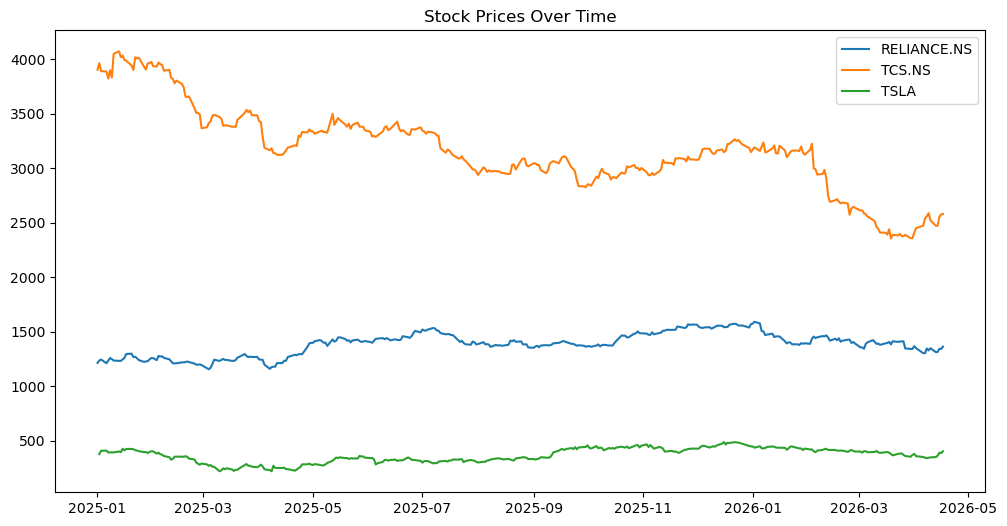

In [32]:
plt.figure(figsize=(12,6))
for stock in close_prices.columns:
    plt.plot(close_prices[stock], label=stock)

plt.title("Stock Prices Over Time")
plt.legend()
plt.show()

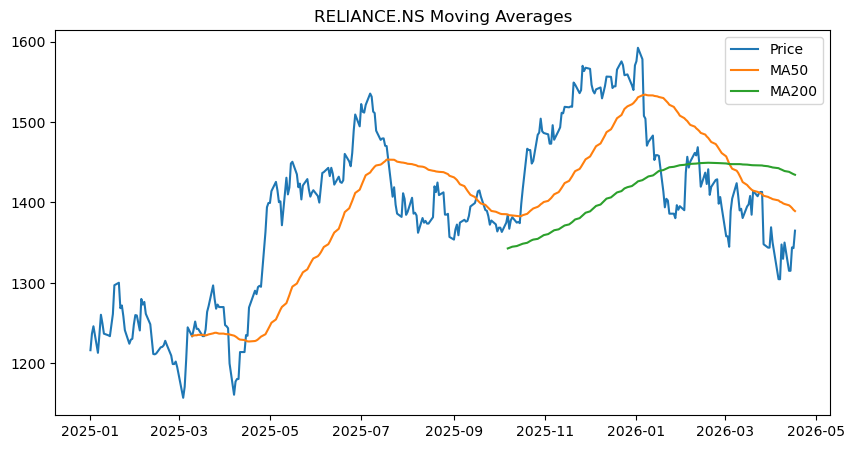

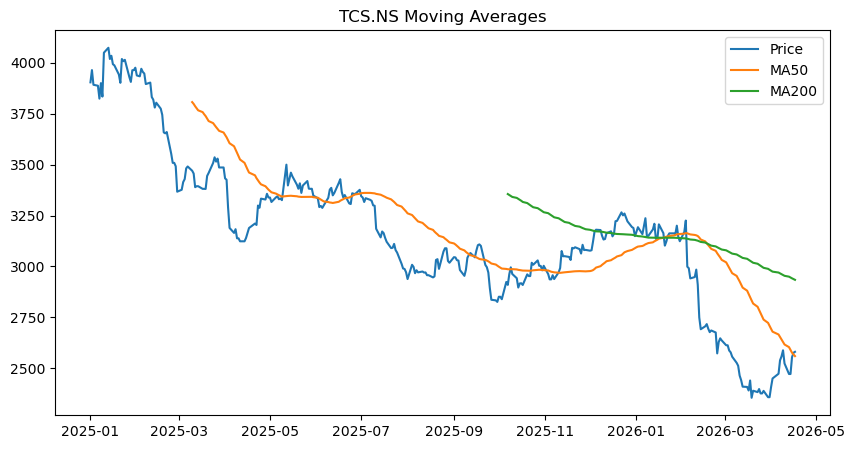

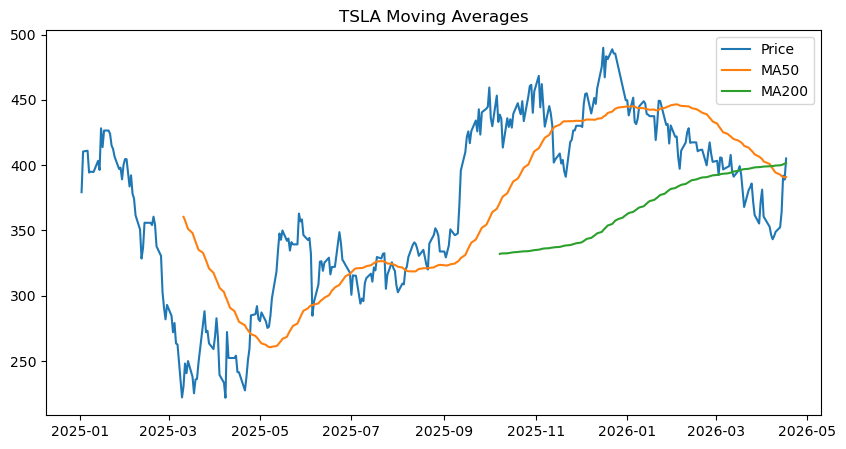

In [42]:
for stock in close_prices.columns:
    plt.figure(figsize=(10,5))
    
    plt.plot(close_prices[stock], label='Price')
    plt.plot(ma50[stock], label='MA50')
    plt.plot(ma200[stock], label='MA200')
    
    plt.title(f"{stock} Moving Averages")
    plt.legend()
    plt.show()

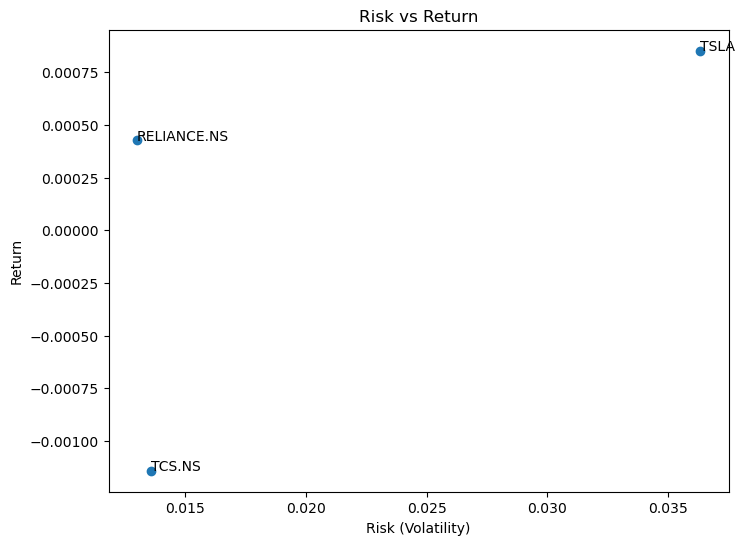

In [35]:
mean_returns = returns.mean()

plt.figure(figsize=(8,6))

plt.scatter(volatility, mean_returns)

for i, stock in enumerate(returns.columns):
    plt.annotate(stock, (volatility[i], mean_returns[i]))

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

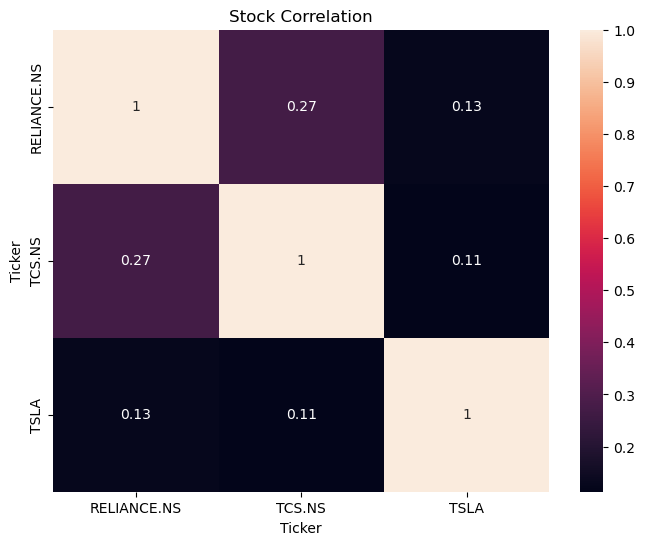

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.title("Stock Correlation")
plt.show()

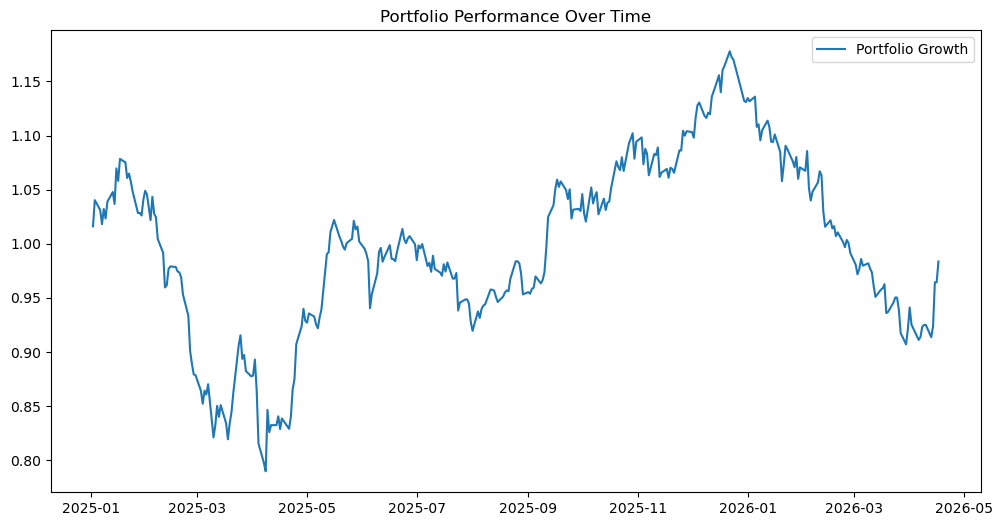

In [48]:
portfolio_returns = returns.mean(axis=1)
portfolio_growth = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(portfolio_growth, label='Portfolio Growth')
plt.title("Portfolio Performance Over Time")
plt.legend()
plt.show()

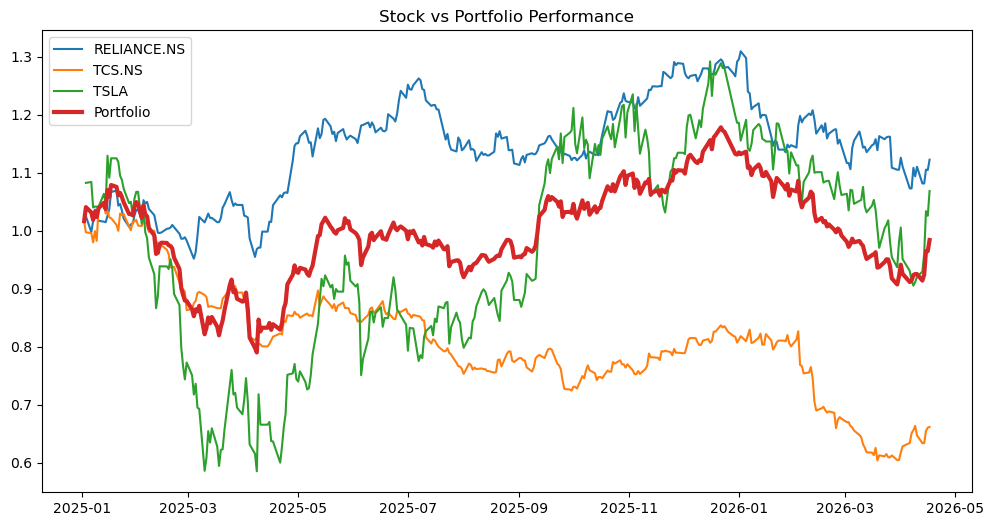

In [49]:
plt.figure(figsize=(12,6))

for stock in returns.columns:
    growth = (1 + returns[stock]).cumprod()
    plt.plot(growth, label=stock)

plt.plot(portfolio_growth, label='Portfolio', linewidth=3)

plt.title("Stock vs Portfolio Performance")
plt.legend()
plt.show()

In [43]:
final_data = returns.copy()
final_data.to_csv(r"C:\Users\rohit\Downloads\stock_returns.csv")